<a href="https://colab.research.google.com/github/MehdiSaraeian/Classification/blob/add-workshop-scenarios/scenarios/03-svm/Scenario_3_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario 3: Finding the Perfect Divide: Classification with Support Vector Machines

This scenario introduces Support Vector Machines (SVMs), a powerful model that finds the optimal hyperplane to separate classes. We'll also explore the 'kernel trick' for non-linear data and use cross-validation for robust evaluation.

## 1. Import Libraries and Prepare Data

As always, we start by importing libraries and preparing our data. **Remember: SVMs are sensitive to the scale of features, so scaling is very important!**

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# --- Data Prep ---
column_names = [
    'id', 'clump_thickness', 'unif_cell_size', 'unif_cell_shape',
    'marg_adhesion', 'single_epith_cell_size', 'bare_nuclei',
    'bland_chrom', 'norm_nucleoli', 'mitoses', 'class'
]
df = pd.read_csv('/content/breast-cancer-wisconsin.data', names=column_names)
df['bare_nuclei'] = df['bare_nuclei'].replace('?', np.nan)
df['bare_nuclei'] = pd.to_numeric(df['bare_nuclei'])
df['bare_nuclei'] = df['bare_nuclei'].fillna(df['bare_nuclei'].median())
df.drop('id', axis=1, inplace=True)
df['class'] = df['class'].map({2: 0, 4: 1})
X = df.drop('class', axis=1)
y = df['class']

# Scale the features *before* splitting for cross-validation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 2. Evaluate an SVM with a Linear Kernel using Cross-Validation

Instead of a single train-test split, we'll use 5-fold cross-validation for a more reliable measure of performance. We'll start with a simple linear kernel.

In [3]:
# HINT: Create an SVC model with kernel='linear'.
# Use cross_val_score() with the model, the scaled data (X_scaled, y), and cv=5.

# YOUR CODE HERE
linear_svm = SVC(kernel='linear', random_state=42)
cv_scores_linear = cross_val_score(linear_svm, X_scaled, y, cv=5)

print("--- SVM with Linear Kernel ---")
print(f"Cross-validation scores: {cv_scores_linear}")
print(f"Average CV score: {cv_scores_linear.mean():.4f}")

--- SVM with Linear Kernel ---
Cross-validation scores: [0.94285714 0.94285714 0.98571429 0.97857143 0.98561151]
Average CV score: 0.9671


## 3. Evaluate an SVM with an RBF Kernel

Now let's try the more flexible RBF (Radial Basis Function) kernel. This kernel can handle non-linear relationships.

In [4]:
# HINT: This is very similar to the step above. Just change the kernel to 'rbf'.

# YOUR CODE HERE
rbf_svm = SVC(kernel='rbf', random_state=42)
cv_scores_rbf = cross_val_score(rbf_svm, X_scaled, y, cv=5)

print("\n--- SVM with RBF Kernel ---")
print(f"Cross-validation scores: {cv_scores_rbf}")
print(f"Average CV score: {cv_scores_rbf.mean():.4f}")


--- SVM with RBF Kernel ---
Cross-validation scores: [0.92857143 0.94285714 0.97857143 0.98571429 0.99280576]
Average CV score: 0.9657


## 4. Final Evaluation of the Best Model

The RBF kernel likely performed better. Let's do a full training run on a training set and get a detailed classification report on the test set.

In [5]:
# HINT: First, do a standard train_test_split on the scaled data.
# Then, create a new RBF SVM, .fit() it on the training set, and .predict() on the test set.

# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

rbf_svm_final = SVC(kernel='rbf', random_state=42)
rbf_svm_final.fit(X_train, y_train)
y_pred = rbf_svm_final.predict(X_test)

print("\n--- Final Evaluation of RBF SVM on Test Set ---")
print(classification_report(y_test, y_pred))


--- Final Evaluation of RBF SVM on Test Set ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        92
           1       0.94      0.94      0.94        48

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140



# Task
Visualize the data distribution and the SVM decision boundary for the provided code.

## Visualize data distribution

### Subtask:
Generate visualizations to show the distribution of features, which can help in understanding the dataset characteristics.


**Reasoning**:
Generate histograms and box plots to visualize the distribution of numerical features and compare distributions between classes.



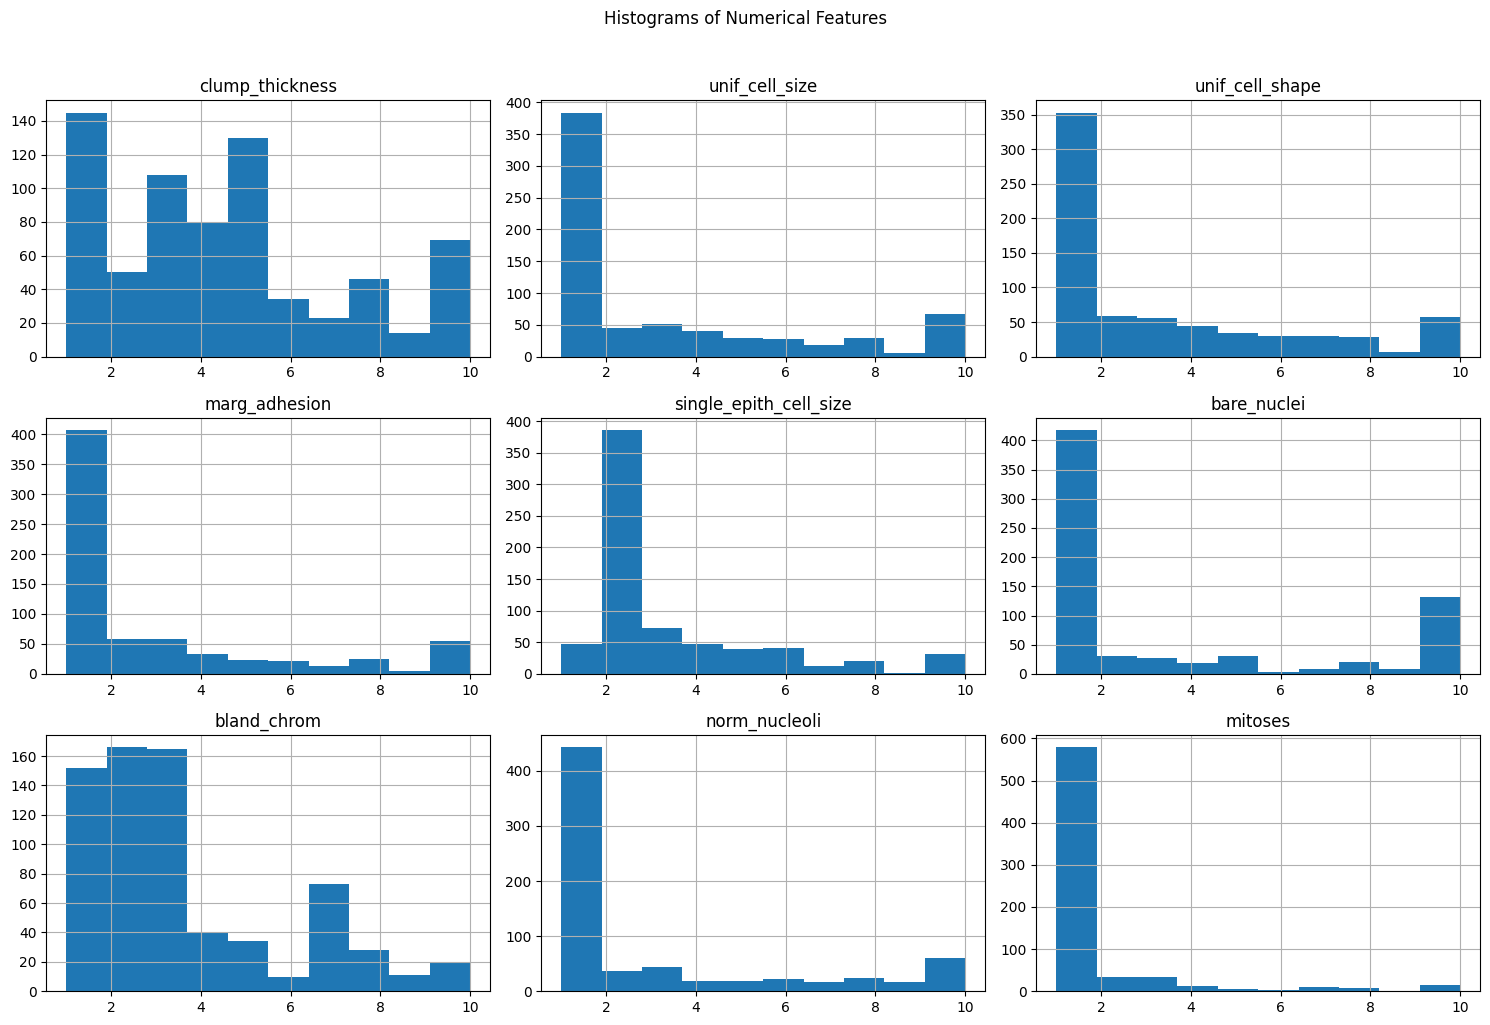

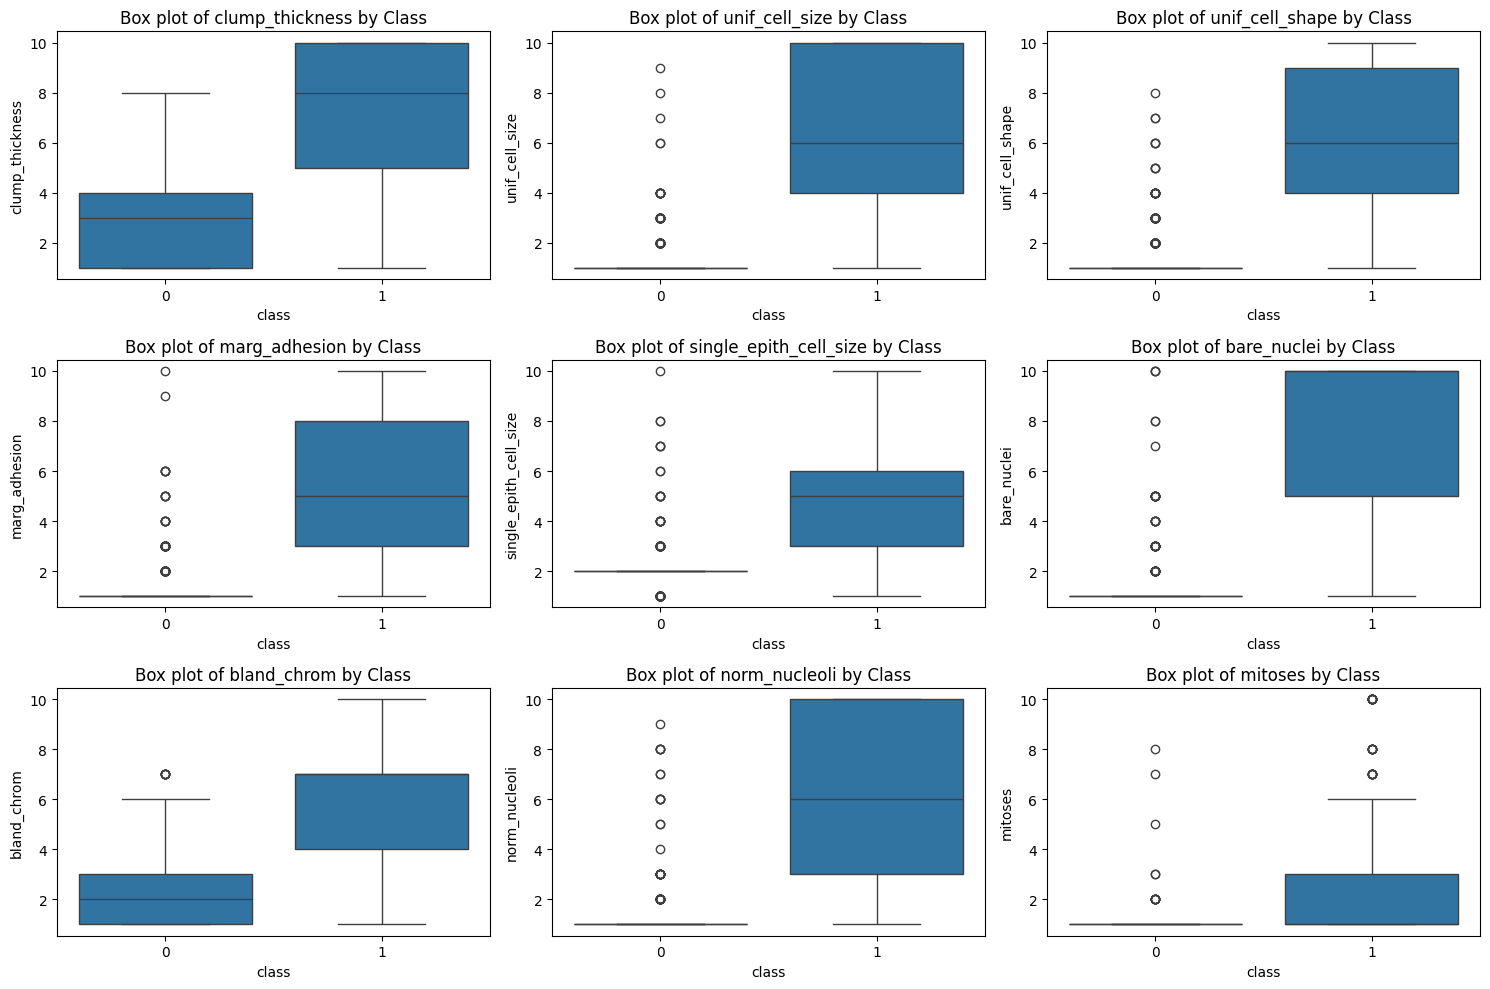

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for plotting
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude the 'class' column for histograms
numerical_cols_hist = [col for col in numerical_cols if col != 'class']

# Plot histograms
df[numerical_cols_hist].hist(figsize=(15, 10))
plt.suptitle("Histograms of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

# Plot box plots grouped by class
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_hist):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='class', y=col, data=df)
    plt.title(f'Box plot of {col} by Class')

plt.tight_layout()
plt.show()

## Visualize svm decision boundary

### Subtask:
Generate code to visualize the decision boundary learned by the SVM model, which can help in understanding how the SVM separates the classes.


**Reasoning**:
Generate code to visualize the decision boundary learned by the SVM model using two selected features.



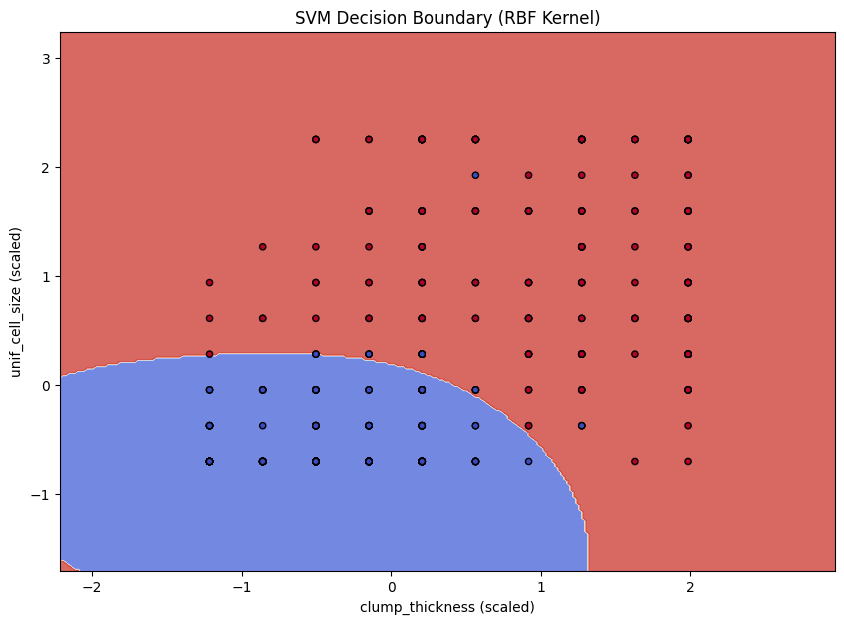

In [7]:
# Select two features for visualization
feature1 = 'clump_thickness'
feature2 = 'unif_cell_size'

X_viz = X[[feature1, feature2]]

# Scale the selected features
scaler_viz = StandardScaler()
X_viz_scaled = scaler_viz.fit_transform(X_viz)

# Create and train a new SVC model
svm_viz = SVC(kernel='rbf', random_state=42)
svm_viz.fit(X_viz_scaled, y)

# Create meshgrid for plotting the decision boundary
x_min, x_max = X_viz_scaled[:, 0].min() - 1, X_viz_scaled[:, 0].max() + 1
y_min, y_max = X_viz_scaled[:, 1].min() - 1, X_viz_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict class for each point in the meshgrid
Z = svm_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and data points
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X_viz_scaled[:, 0], X_viz_scaled[:, 1], c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')

# Add labels and title
plt.xlabel(feature1 + ' (scaled)')
plt.ylabel(feature2 + ' (scaled)')
plt.title('SVM Decision Boundary (RBF Kernel)')
plt.show()

## Summary:

### Data Analysis Key Findings
* The distributions of numerical features were visualized using histograms, and their relationship with the target variable `class` was explored through box plots.
* An SVM model was trained using the `clump_thickness` and `unif_cell_size` features to visualize the decision boundary. The resulting plot illustrates how the SVM with an RBF kernel separates the two classes in a 2D feature space.

### Insights or Next Steps
* Based on the initial visualizations, it appears that several features have different distributions for benign and malignant classes, suggesting their potential predictive power.
* The visualized SVM decision boundary shows a clear separation between the two classes based on the selected features. Further analysis could involve exploring other feature combinations or different kernel types to potentially improve the model's performance.
